# CNN Model Intro with Fashion MNIST Implementation
### Brief Introduction
This notebook will cover the following two major topics :

#### Understand the basic concepts of CNN model
#### Implement CNN model in realtime using Fashion MNIST dataset

## Understand the basic concepts of CNN model :

Mankind is an awesome natural machine and is capable of looking at multiple images every second and process them without realizing how the processing is done. But same is not with machines. 

The first step in image processing is to understand, how to represent an image so that the machine can read it?

Every image is an cumulative arrangement of dots (a pixel) arranged in a special order. If you change the order or color of a pixel, the image would change as well. 

![](https://ujwlkarn.files.wordpress.com/2016/08/screen-shot-2016-08-07-at-9-15-21-pm.png)
Three basic components to define a basic convolutional neural network.

### The Convolutional Layer
### The Pooling layer
### The Output layer

Let’s see each of them in detail

### The Convolutional Layer :

In this layer if we have an image of size 6*6. We define a weight matrix which extracts certain features from the images*
![](https://cdn.analyticsvidhya.com/wp-content/uploads/2017/06/28010254/conv1.png)
We have initialized the weight as a 3*3 matrix. This weight shall now run across the image such that all the pixels are covered at least once, to give a convolved output. The value 429 above, is obtained by the adding the values obtained by element wise multiplication of the weight matrix and the highlighted 3*3 part of the input image.
![](https://cdn.analyticsvidhya.com/wp-content/uploads/2017/06/28011851/conv.gif)
The 6*6 image is now converted into a 4*4 image.  Think of weight matrix like a paint brush painting a wall. The brush first paints the wall horizontally and then comes down and paints the next row horizontally. Pixel values are used again when the weight matrix moves along the image. This basically enables parameter sharing in a convolutional neural network.

Let’s see how this looks like in a real image.
![](https://cdn.analyticsvidhya.com/wp-content/uploads/2017/06/28132834/convimages.png)

* The weight matrix behaves like a filter in an image, extracting particular information from the original image matrix. 
* A weight combination might be extracting edges, while another one might a particular color, while another one might just blur the unwanted noise.
* The weights are learnt such that the loss function is minimized and extract features from the original image which help the network in correct prediction.
* When we use multiple convolutional layers, the initial layer extract more generic features,and as network gets deeper the features get complex.

Let us understand some concepts here before we go further deep

#### What is Stride?

As shown above above, the filter or the weight matrix we moved across the entire image moving one pixel at a time.If this is a hyperparameter to move weight matrix 1 pixel at a time across image it is called as stride of 1. Let us see for stride of 2 how it looks.
![](https://cdn.analyticsvidhya.com/wp-content/uploads/2017/06/28090227/stride1.gif)

As you can see the size of image keeps on reducing as we increase the stride value. 

Padding the input image with zeros across it solves this problem for us. We can also add more than one layer of zeros around the image in case of higher stride values.
![](https://cdn.analyticsvidhya.com/wp-content/uploads/2017/06/28093553/zero-padding.png)
We can see how the initial shape of the image is retained after we padded the image with a zero. This is known as same padding since the output image has the same size as the input. 
![](https://cdn.analyticsvidhya.com/wp-content/uploads/2017/06/28094927/padding.gif)
This is known as same padding (which means that we considered only the valid pixels of the input image). The middle 4*4 pixels would be the same. Here we have retained more information from the borders and have also preserved the size of the image.

#### Having Multiple filters & the Activation Map

* The depth dimension of the weight would be same as the depth dimension of the input image.
* The weight extends to the entire depth of the input image. 
* Convolution with a single weight matrix would result into a convolved output with a single depth dimension. In case of multiple filters all have same dimensions applied together.
* The output from the each filter is stacked together forming the depth dimension of the convolved image. 

Suppose we have an input image of size 32*32*3. And we apply 10 filters of size 5*5*3 with valid padding. The output would have the dimensions as 28*28*10.

You can visualize it as –
![](https://cdn.analyticsvidhya.com/wp-content/uploads/2017/06/28113904/activation-map.png)
This activation map is the output of the convolution layer.

### The Pooling Layer

If images are big in size, we would need to reduce the no.of trainable parameters.For this we need to use pooling layers between convolution layers. Pooling is used for reducing the spatial size of the image and is implemented independently on each depth dimension resulting in no change in image depth. Max pooling is the most popular form of pooling layer.
![](https://cdn.analyticsvidhya.com/wp-content/uploads/2017/06/28022816/maxpool.png)
Here we have taken stride as 2, while pooling size also as 2. The max operation is applied to each depth dimension of the convolved output. As you can see, the 4*4 convolved output has become 2*2 after the max pooling operation.

Let’s see how max pooling looks on a real image.
![](https://cdn.analyticsvidhya.com/wp-content/uploads/2017/06/28133544/pooling.png)
In the above image we have taken a convoluted image and applied max pooling on it which resulted in still retaining the image information that is a car but if we closely observe the dimensions of the image is reduced to half which basically means we can reduce the parameters to a great number.

There are other forms of pooling like average pooling, L2 norm pooling.

#### Output dimensions

It is tricky at times to understand the input and output dimensions at the end of each convolution layer. For this we will use three hyperparameters that would control the size of output volume.

1. No of Filter: The depth of the output volume will be equal to the number of filter applied.The depth of the activation map will be equal to the number of filters.

2. Stride – When we have a stride of one we move across and down a single pixel. With higher stride values, we move large number of pixels at a time and hence produce smaller output volumes.

3. Zero padding – This helps us to preserve the size of the input image. If a single zero padding is added, a single stride filter movement would retain the size of the original image.

We can apply a simple formula to calculate the output dimensions.

The spatial size of the output image can be calculated as( [W-F+2P]/S)+1. 
where, W is the input volume size, 
       F is the size of the filter, 
       P is the number of padding applied 
       S is the number of strides. 
       
Let us take an example of an input image of size 64*64*3, we apply 10 filters of size 3*3*3, with single stride and no zero padding.

Here W=64, F=3, P=0 and S=1. The output depth will be equal to the number of filters applied i.e. 10.

The size of the output volume will be ([64-3+0]/1)+1 = 62. Therefore the output volume will be 62*62*10.

### The Output layer
* With no of layers of convolution and padding, we need the output in the form of a class.
* To generate the final output we need to apply a fully connected layer to generate an output equal to the number of classes we need.
* Convolution layers generate 3D activation maps while we just need the output as whether or not an image belongs to a particular class. 
* The Output layer has a loss function like categorical cross-entropy, to compute the error in prediction. Once the forward pass is complete the backpropagation begins to update the weight and biases for error and loss reduction.

### Summary:
* Pass an input image to the first convolutional layer. The convoluted output is obtained as an activation map. The filters applied in the convolution layer extract relevant features from the input image to pass further.
* Each filter shall give a different feature to aid the correct class prediction. In case we need to retain the size of the image, we use same padding(zero padding), otherwise valid padding is used since it helps to reduce the number of features.
* Pooling layers are then added to further reduce the number of parameters
* Several convolution and pooling layers are added before the prediction is made. Convolutional layer help in extracting features. As we go deeper in the network more specific features are extracted as compared to a shallow network where the features extracted are more generic.
* The output layer in a CNN as mentioned previously is a fully connected layer, where the input from the other layers is flattened and sent so as the transform the output into the number of classes as desired by the network.
* The output is then generated through the output layer and is compared to the output layer for error generation. A loss function is defined in the fully connected output layer to compute the mean square loss. The gradient of error is then calculated.
* The error is then backpropagated to update the filter(weights) and bias values.
* One training cycle is completed in a single forward and backward pass.



### Implement CNN model in realtime using Garbage Classification


### Context
This dataset has 15,150 images from 12 different classes of household garbage; paper, cardboard, biological, metal, plastic, green-glass, brown-glass, white-glass, clothes, shoes, batteries, and trash.

Garbage Recycling is a key aspect of preserving our environment. To make the recycling process possible/easier, the garbage must be sorted to groups that have similar recycling process. I found that most available data sets classify garbage into a few classes (2 to 6 classes at most). Having the ability to sort the household garbage into more classes can result in dramatically increasing the percentage of the recycled garbage.

### Content
An ideal setting for data collection would be to place a camera above a conveyor where the garbage comes one by one, so that the camera can capture real garbage images. But since such a setup is not feasible at the moment I collected most of the images in this dataset by web scraping, I tried to get images close to garbage images whenever possible, for example in biological garbage category I searched for rotten vegetables, rotten fruits and food remains, etc. However, for some classes such as clothes or shoes it was more difficult to get images of clothes or shoes from the garbage, so mostly it was images of normal clothes. Nevertheless, being able to classify the images of this data set to 12 classes can be a big step towards improving the recycling process.

### Acknowledgements
The clothes category and 22 % of the shoes' category were obtained from the Clothing dataset https://www.kaggle.com/agrigorev/clothing-dataset-full
Around 29% of the other 9 classes combined was collected from the Garbage Classification dataset https://www.kaggle.com/asdasdasasdas/garbage-classification
All the rest of the images were obtained using Web Scrapping.
All the images collected using web scrapping are owned by their original photographers/owners. The images are only used to promote research and is not used to generate any profit. Any of the images in the data set can be deleted upon the request of the original photographer/owner.

View less


In [1]:
import os
import numpy as np
import tensorflow as tf
import random
import glob
import pandas as pd
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
train_dir = 'C:/Users/awadh/Waste/garbage_classification'

In [4]:
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32

In [5]:
categories = os.listdir(train_dir)
print("categories : " , categories)

categories :  ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


In [6]:
images = []
labels = []

for class_folder in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_folder)
    
    if not os.path.isdir(class_path):
        continue
    
    print(f"{class_folder}")
    
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        
        if not os.path.isfile(img_path) or not img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
            
       
        img = Image.open(img_path)
        img = img.convert('RGB')
        img = img.resize((IMG_HEIGHT, IMG_WIDTH))  
        img_array = np.array(img)
       
        
        images.append(img_array)
        labels.append(class_folder)
            
       
images = np.array(images)
labels = np.array(labels)

print(f"{len(images)} ")
print(f"{len(np.unique(labels))}")

battery
biological
brown-glass
cardboard
clothes
green-glass
metal
paper
plastic
shoes
trash
white-glass
15515 
12


In [7]:
pd.value_counts(labels)

C:\Users\awadh\AppData\Local\Temp\ipykernel_21432\2812286946.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(labels)
C:\Users\awadh\AppData\Local\Temp\ipykernel_21432\2812286946.py:1: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  pd.value_counts(labels)


clothes        5325
shoes          1977
paper          1050
biological      985
battery         945
cardboard       891
plastic         865
white-glass     775
metal           769
trash           697
green-glass     629
brown-glass     607
Name: count, dtype: int64

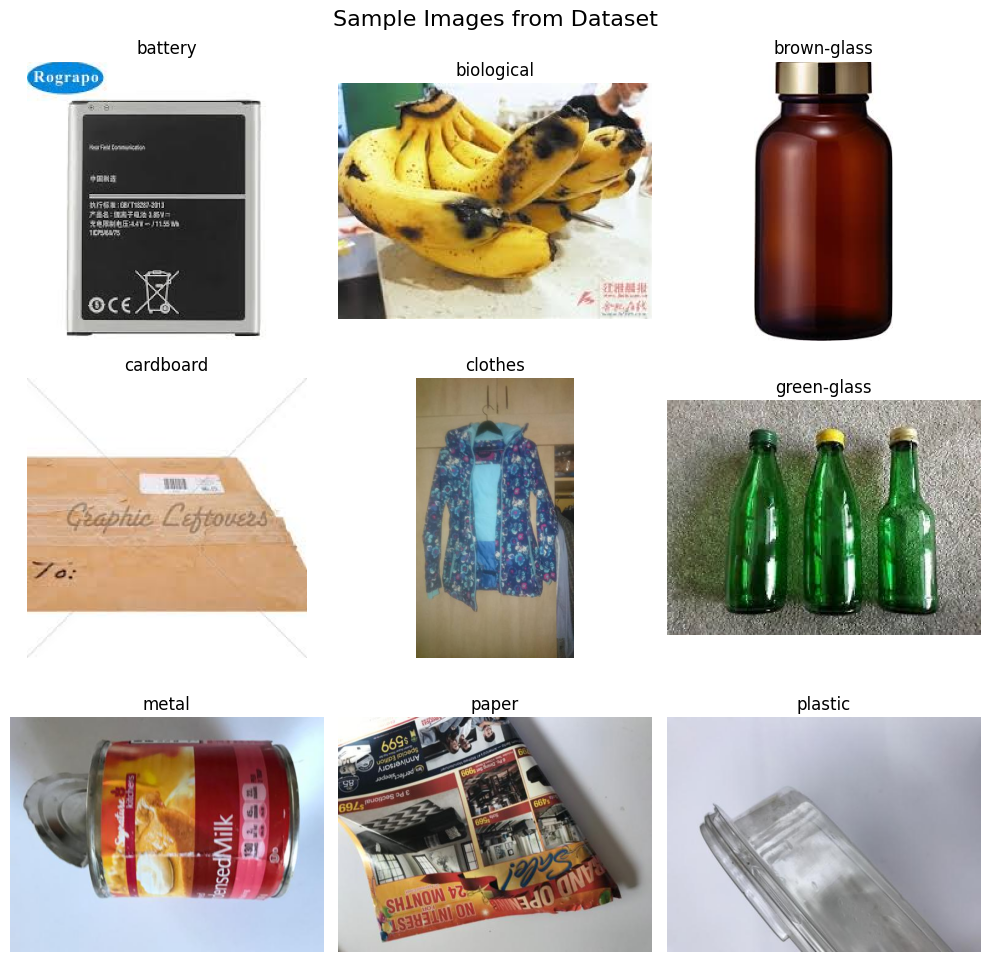

In [8]:
# print smples
plt.figure(figsize=(10, 10))
for i, category in enumerate(categories[:9]):
    folder = os.path.join(train_dir, category)
    img_path = random.choice(glob.glob(folder + "/*.jpg"))
    img = plt.imread(img_path)
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')
plt.suptitle("Sample Images from Dataset", fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print("Number of classes:", num_classes)
print("Class mapping:", train_generator.class_indices)

Found 12415 images belonging to 12 classes.
Found 3100 images belonging to 12 classes.
Number of classes: 12
Class mapping: {'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}


In [10]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 31, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 12544)             0         
                                                                 
 dense (Dense)               (None, 128)               1

In [12]:
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator
)

Epoch 1/30
388/388 [==============================] - 16s 35ms/step - loss: 1.5675 - accuracy: 0.4851 - val_loss: 1.3027 - val_accuracy: 0.6065
Epoch 2/30
388/388 [==============================] - 13s 34ms/step - loss: 1.2233 - accuracy: 0.5964 - val_loss: 1.1670 - val_accuracy: 0.6139
Epoch 3/30
388/388 [==============================] - 13s 34ms/step - loss: 1.0573 - accuracy: 0.6538 - val_loss: 1.0943 - val_accuracy: 0.6477
Epoch 4/30
388/388 [==============================] - 14s 35ms/step - loss: 0.9301 - accuracy: 0.6895 - val_loss: 0.9929 - val_accuracy: 0.6671
Epoch 5/30
388/388 [==============================] - 14s 36ms/step - loss: 0.8439 - accuracy: 0.7210 - val_loss: 1.0013 - val_accuracy: 0.6748
Epoch 6/30
388/388 [==============================] - 14s 36ms/step - loss: 0.7666 - accuracy: 0.7477 - val_loss: 0.9701 - val_accuracy: 0.6858
Epoch 7/30
388/388 [==============================] - 15s 37ms/step - loss: 0.6834 - accuracy: 0.7702 - val_loss: 0.9334 - val_accuracy:

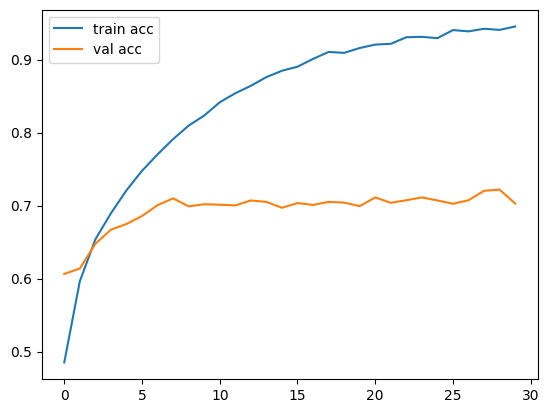

In [14]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [15]:
val_generator.reset()
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

97/97 [==============================] - 3s 32ms/step


In [16]:
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=list(val_generator.class_indices.keys())))

Classification Report:
              precision    recall  f1-score   support

     battery       0.71      0.53      0.61       189
  biological       0.72      0.60      0.65       197
 brown-glass       0.78      0.63      0.69       121
   cardboard       0.71      0.64      0.67       178
     clothes       0.85      0.95      0.89      1065
 green-glass       0.82      0.75      0.78       125
       metal       0.31      0.44      0.37       153
       paper       0.62      0.66      0.64       210
     plastic       0.53      0.58      0.56       173
       shoes       0.65      0.73      0.68       395
       trash       0.73      0.29      0.42       139
 white-glass       0.33      0.22      0.26       155

    accuracy                           0.70      3100
   macro avg       0.65      0.59      0.60      3100
weighted avg       0.70      0.70      0.69      3100



<Axes: >

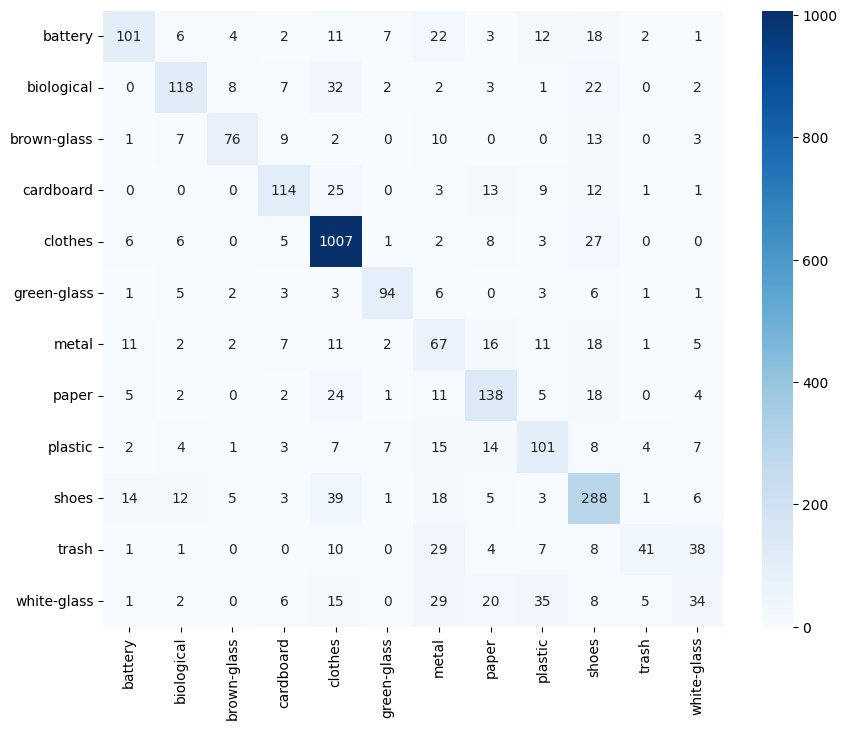

In [17]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(val_generator.class_indices.keys()), yticklabels=list(val_generator.class_indices.keys()))

In [18]:
# Save the model in the HDF5 (.h5) format
model.save('C:/Users/awadh/Waste/my_waste_model.h5')
print("Model saved successfully as 'my_waste_model.h5'.")

Model saved successfully as 'my_waste_model.h5'.


In [19]:
# -------------------------------
# LOAD MODEL
# -------------------------------
model_path = 'C:/Users/awadh/Waste/my_waste_model.h5'
model = load_model(model_path, compile=False)

# -------------------------------
# CLASS LABELS
# -------------------------------
class_labels = ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']



In [20]:
# -------------------------------
# IMAGE PREPROCESSING
# -------------------------------
def preprocess_image(train_path, target_size=(64, 64)):
    """Load image, resize, normalize and expand dimensions for prediction."""
    img = Image.open(train_path).convert("RGB")
    img = img.resize(target_size)
    img_array = np.array(img).astype("float32") / 255.0
    return np.expand_dims(img_array, axis=0)

# -------------------------------
# PREDICTION FUNCTION
# -------------------------------
def predict_image(train_path):
    """Predict and return figure + label instead of showing directly."""
    x = preprocess_image(train_path)
    x = tf.convert_to_tensor(x)

    with tf.device("/CPU:0"):
        preds = model(x, training=False).numpy()

    idx = np.argmax(preds, axis=1)[0]
    label = class_labels[idx]
    conf = preds[0][idx] * 100

    # Plot image
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(Image.open(img_path))
    ax.axis("off")
    ax.set_title(f"Predicted: {label} ({conf:.2f}%)", fontsize=12)

    # Return figure and details
    return fig, label, conf, os.path.basename(img_path)



In [21]:

# -------------------------------
# TEST IMAGE SEARCH
# -------------------------------
valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.jfif')

# Search recursively for images in subfolders
image_files = []
for root, dirs, files in os.walk(train_dir):
    for f in files:
        if f.lower().endswith(valid_ext):
            image_files.append(os.path.join(root, f))

# Relative paths for dropdown display
dropdown_options = [os.path.relpath(f, train_dir) for f in image_files]

print(f"✅ Found {len(image_files)} images for prediction.")

# -------------------------------
# WIDGETS
# -------------------------------
dropdown = widgets.Dropdown(
    options=dropdown_options if dropdown_options else ["(no images found)"],
    description="Choose Image:",
    layout=widgets.Layout(width="60%")
)

count_box = widgets.BoundedIntText(
    value=1,
    min=1,
    max=max(1, len(image_files)),
    step=1,
    description="How many:",
    layout=widgets.Layout(width="60%")
)

button = widgets.Button(description="Predict ✅", button_style="success")
output = widgets.Output()

# -------------------------------
# BUTTON CALLBACK
# -------------------------------
def on_submit(b):
    output.clear_output()
    with output:
        if not image_files:
            print("⚠️ No images found in the test directory.")
            return

        start_index = dropdown_options.index(dropdown.value)
        num = min(count_box.value, len(image_files) - start_index)
        selected_files = image_files[start_index:start_index + num]

        for f in selected_files:
            fig, label, conf, filename = predict_image(f)
            display(fig)
            print(f"📂 File: {filename}")
            print(f"✅ Prediction: {label} ({conf:.2f}%)\n")
            plt.close(fig)

button.on_click(on_submit)

# -------------------------------
# DISPLAY UI
# -------------------------------
display(widgets.VBox([dropdown, count_box, button, output]))

✅ Found 15515 images for prediction.
